# **Reconhecimento facial com VGGFace no Keras**

---


Nesta lição, usamos o **Reconhecimento facial com VGGFace no Keras** para comparar a semelhança facial. Carregamos um modelo pré-treinado do VGGFace (treinado em milhares de rostos) e o usamos, juntamente com uma métrica de semelhança, para definir se dois rostos são da mesma pessoa.

1. Baixe nossos dados e importe nossos módulos
2. Defina nosso modelo VGGFace e carregue nossos pesos
3. Crie nossa função de distância cosseno
4. Verificando a semelhança facial
5. Reconhecimento facial com aprendizado One Shot
6. Teste o modelo usando sua webcam


Artigo relacionado - https://www.robots.ox.ac.uk/~vgg/publications/2015/Parkhi15/parkhi15.pdf


### Usando o dataset LFW people

In [7]:
!curl -L -o ./lfwpeople.zip\
  https://www.kaggle.com/api/v1/datasets/download/atulanandjha/lfwpeople

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  232M  100  232M    0     0  13.2M      0  0:00:17  0:00:17 --:--:-- 11.8M


In [8]:
!unzip -q lfwpeople.zip

In [40]:
# Kaggle dataset paths
import os
import tarfile
LFW_DATASET_PATH = "."
LFW_TGZ = os.path.join(LFW_DATASET_PATH, "lfw-funneled.tgz")
PAIRS_FILE = os.path.join(LFW_DATASET_PATH, "pairs.txt")
WORK_DIR = "."

# Extract the dataset
LFW_EXTRACTED_DIR = os.path.join(WORK_DIR, "lfw_funneled")

if not os.path.exists(LFW_EXTRACTED_DIR):
    print("📦 Extracting LFW dataset...")
    with tarfile.open(LFW_TGZ, 'r:gz') as tar:
        tar.extractall(WORK_DIR)
    print(f"✅ Extracted to: {LFW_EXTRACTED_DIR}")
else:
    print(f"✅ Dataset already extracted at: {LFW_EXTRACTED_DIR}")

# Verify extraction
num_people = len([d for d in os.listdir(LFW_EXTRACTED_DIR) if os.path.isdir(os.path.join(LFW_EXTRACTED_DIR, d))])
print(f"📊 Found {num_people} people in dataset")

✅ Dataset already extracted at: ./lfw_funneled
📊 Found 5749 people in dataset


In [41]:
# Import our libaries
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Convolution2D, ZeroPadding2D, MaxPooling2D, Flatten, Dense, Dropout, Activation
from PIL import Image
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, save_img, img_to_array
from tensorflow.keras.applications.imagenet_utils import preprocess_input
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

In [42]:
model = Sequential()
model.add(ZeroPadding2D((1,1),input_shape=(224,224, 3)))
model.add(Convolution2D(64, (3, 3), activation='relu'))
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2,2), strides=(2,2)))

model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(128, (3, 3), activation='relu'))
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2,2), strides=(2,2)))

model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(256, (3, 3), activation='relu'))
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(256, (3, 3), activation='relu'))
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(256, (3, 3), activation='relu'))
model.add(MaxPooling2D((2,2), strides=(2,2)))

model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(512, (3, 3), activation='relu'))
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(512, (3, 3), activation='relu'))
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(512, (3, 3), activation='relu'))
model.add(MaxPooling2D((2,2), strides=(2,2)))

model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(512, (3, 3), activation='relu'))
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(512, (3, 3), activation='relu'))
model.add(ZeroPadding2D((1,1)))
model.add(Convolution2D(512, (3, 3), activation='relu'))
model.add(MaxPooling2D((2,2), strides=(2,2)))

model.add(Convolution2D(4096, (7, 7), activation='relu'))
model.add(Dropout(0.5))
model.add(Convolution2D(4096, (1, 1), activation='relu'))
model.add(Dropout(0.5))
model.add(Convolution2D(2622, (1, 1)))
model.add(Flatten())
model.add(Activation('softmax'))

Baixe o modelo pre treinado - https://www.kaggle.com/datasets/vincentscheltjens/vgg-face-weightsh5

In [43]:
model.load_weights('vgg_face_weights.h5')

## **Criando a função de distancia de cosseno**

![Image of Cosine Similarity](https://raw.githubusercontent.com/rajeevratan84/DeepLearningCV/master/cosine.JPG)
![Image of Cosine Similarity Formula](https://raw.githubusercontent.com/rajeevratan84/DeepLearningCV/master/cosinesim.JPG)

In [44]:
def preprocess_image(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    return img

def findCosineSimilarity(source_representation, test_representation):
    a = np.matmul(np.transpose(source_representation), test_representation)
    b = np.sum(np.multiply(source_representation, source_representation))
    c = np.sum(np.multiply(test_representation, test_representation))
    return 1 - (a / (np.sqrt(b) * np.sqrt(c)))

# Our model that outputs the 2,622 embedding vector
vgg_face_descriptor = Model(inputs=model.layers[0].input, outputs=model.layers[-2].output)

## **Verificando semelhança facial**

#### **Definindo nossa função verifyFace, onde carregamos duas imagens de rostos e as comparamos.**

Definimos **epsilon** como o limite para determinar se os dois rostos são da mesma pessoa. Definir um valor mais baixo torna a correspondência facial mais rigorosa.

In [45]:
epsilon = 0.40

def verifyFace(img1, img2):
    # Get embedding/encoding for face1 and face2
    img1_representation = vgg_face_descriptor.predict(preprocess_image('./lfw_funneled/%s' % (img1)))[0,:]
    img2_representation = vgg_face_descriptor.predict(preprocess_image('./lfw_funneled/%s' % (img2)))[0,:]
    
    # Calculate the cosine similarity between the two embeddings
    cosine_similarity = findCosineSimilarity(img1_representation, img2_representation)
    
    f = plt.figure()
    f.add_subplot(1,2, 1)
    plt.imshow(image.load_img('./lfw_funneled/%s' % (img1)))
    plt.xticks([]); plt.yticks([])
    f.add_subplot(1,2, 2)
    plt.imshow(image.load_img('./lfw_funneled/%s' % (img2)))
    plt.xticks([]); plt.yticks([])
    plt.show(block=True)
    
    print("Cosine similarity: ",cosine_similarity)
    
    # If similarity score is less than the epsilon threshold
    if(cosine_similarity < epsilon):
        print("They are same person")
    else:
        print("They are not same person!")

### **Testes**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


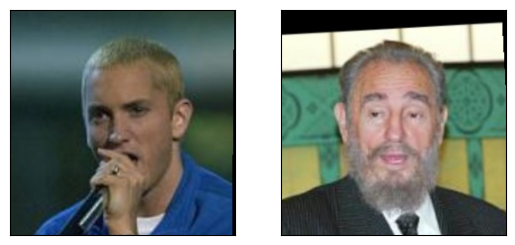

Cosine similarity:  0.4663059
They are not same person!


In [46]:
# Let's compare two faces of the same person
verifyFace("Eminem/Eminem_0001.jpg", "Fidel_Castro/Fidel_Castro_0014.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


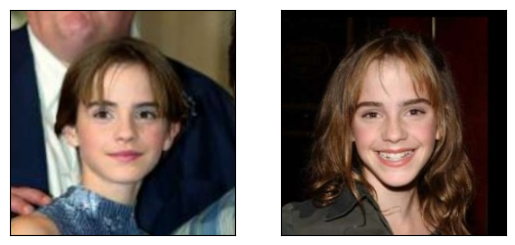

Cosine similarity:  0.20575315
They are same person


In [47]:
# Let's now try it on 2nd picture of the same person
verifyFace("Emma_Watson/Emma_Watson_0001.jpg", "Emma_Watson/Emma_Watson_0003.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


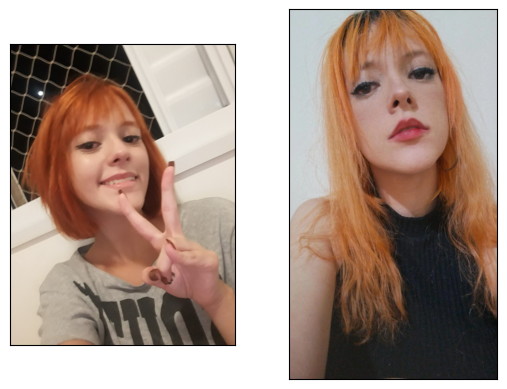

Cosine similarity:  0.28944468
They are same person


In [55]:
verifyFace("Duda/Duda2.jpeg", "Duda/Duda3.jpeg")